# **4.** Learning: How to train an AI algorithm?

Now that we know how to work with datasets, and we have identified useful features for each problem we're going to tackle, we can start with the interesting part: How do we train a machine to make a decisions?

We will explore a machine learning paradigm called **supervised learning**. Supervised learning is a type of machine learning where the computer learns from data that **includes the "right answers"** - in other words, each example comes with a label that tells the model what the correct output should be. The goal is for the model to learn the relationship between the input data and these labels, so it can make **accurate predictions on new, unseen data.**

For example:
- Predicting tomorrow's temperature based on past weather data
- Classifying news articles by topic (e.g. politics, sports, entertainment)
- Detecting fraudulent transactions by learning from examples of both normal and fraudulent activity

In our case, we're going to use supervised learning to train a model for each of the tasks we discussed in the previous notebook:
* Classifying movie reviews into positive or negative
* Classifying instruments into musical families
* Classifying images into object categories

## Nearest Neighbour

Imagine we are analysing data that corresponds to two different classes: class A and class B. And let's say we have the value of two features, feature_1 and feature_2, for every data sample.

The data might look something like this:

In [1]:
toy_data_string = """feature_1,feature_2,class
0.1,0.2,A
0.2,0.1,A
0.8,0.9,B
0.9,0.8,B
0.5,0.5,A
0.6,0.6,B
0.3,0.4,A
0.4,0.3,A
0.7,0.8,B"""

In this case we can see a nice 2D plot showing where each sample is in the plane formed by the two features.

<Axes: xlabel='feature_1', ylabel='feature_2'>

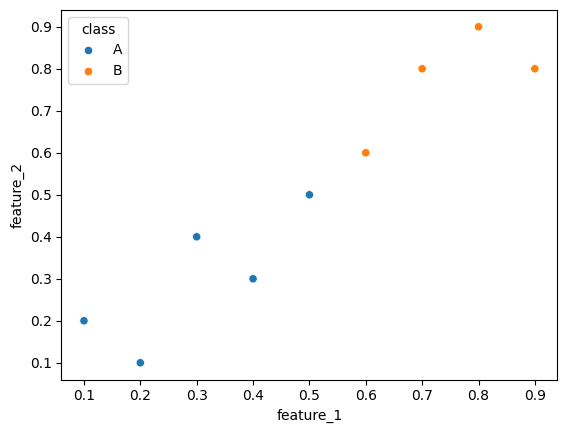

In [2]:
from io import StringIO
import pandas as pd
import seaborn as sns

X_train = pd.read_csv(StringIO(toy_data_string))
sns.scatterplot(data=X_train, x="feature_1", y="feature_2", hue="class")

Now, imagine we have a new data point, and we don't know its class yet:

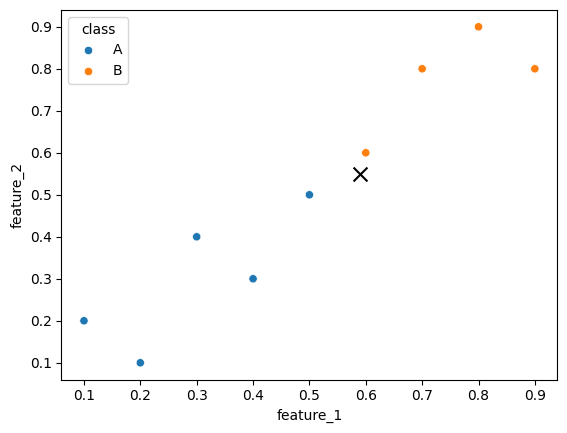

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x_test = np.array([0.59, 0.55], dtype=float)
sns.scatterplot(data=X_train, x="feature_1", y="feature_2", hue="class")
plt.scatter(x_test[0], x_test[1], c='black', marker='x', s=100)

> Looking at the plot, what class would you assign to it and why?

In this example, you would probably look at which sample of data is closest to the one we are trying to classify, and use the same label they have! In this case, it looks like it's closer to a point with class B. This is exactly the reasoning behind the **Nearest Neighbour** algorithm. This algorithm remembers all the features and classes of the data it was trained with. For a previously unseen data sample, it checks which is the training sample that's closest, and then, it assigns the class of its nearest neighbor to the new sample.


We can define it formally as it follows:

Given a test point $x^*$ and a dataset of points $x_{train} = \{x_{train_1}, x_{train_2}, \ldots, x_{train_n}\}$, 
the Nearest Neighbor algorithm finds the point $x_{train}^*$ that minimizes a distance function $d$:

$$x_{train}^* = \arg\min_{{x_{train_i} \in x_{train}}} \, d(x^*, x_{train_i})$$

where the distance between two points is defined in this case as:

$$d(x^*, x_{train_i}) = \sqrt{(\text{feature}_1(x^*) - \text{feature}_1(x_{train_i}))^2 + (\text{feature}_2(x^*) - \text{feature}_2(x_{train_i}))^2}$$

The algorithm then assigns the class of $x_{train}^*$ to the test point $x^*$.

If we have N features, we can modify the distance function to:

$$d(x^*, x_{\text{train}_i}) = \sqrt{\sum_{j=1}^{N}(\text{feature}_j(x^*) - \text{feature}_j(x_{\text{train}_i}))^2}$$


What would this look like for our data? First, we need to compute the distances to all the points we trained the classifier with.

In [4]:
import numpy as np

diff = x_test - X_train.values[:, :2].astype(float)
distances = np.sqrt(np.sum(np.square(diff), axis=1))

Then, we need to check which is the data sample that's the closest to the new sample we want to classify. In other words, which sample of data minimises the distance function.

In [5]:
X_train.iloc[np.argmin(distances)]

feature_1    0.6
feature_2    0.6
class          B
Name: 5, dtype: object

Then, we can say that our new test sample should be classified as belonging to class B!

## $k$-Nearest Neighbours

A way extending the previous idea to get a more robust classifier is to use a **k-Nearest Neighbours** algorithm.

The idea is very similar. $k$-NN uses the feature vector assigned to each data point. When predicting this point's label, it computes the **distance** between this point and all points in the training set. Then, it selects the $k$ closest points from the training data (hence, $k$-nearest neighbours!). The predicted label is typically the majority label among these neighbours.

We will need to choose the value of $k$ (how many neighbours we're searching for) that gives us the best result as we fit our model!

> Note that, since we're choosing the label as the majority label, it makes sense to choose a odd number as $k$

## Data Splitting ➗

### Train, validation and test sets

Before we can start with supervised learning, we need to **split our data**. Why do we do this? Imagine we train our model with all our data, and spend a lot of effort trying to make it perform well for it. The problem is will still have no idea of how the model reacts to data it has never seen. It might as well be getting super good at memorising only those particular cases!

How best to split a dataset depends on many qualities, including how it was made and the number of data points within it. For now, we're just going to split our dataset into three separate parts:
- The **train set** consists of the data points we'll use to train the model;
- The **evaluation set** consists of the data points we'll use to evaluate the model's performance when trying different model configurations and parameters (we might refer to this as **hyperparameter tuning**);
- The **test set** consists of the data points we'll use to evaluate how well it performs **after** we've finished the training process and are happy with our model. This gives us an idea of how the model will perform with new unseen data.

We need all these splits of the dataset to truly understand our model: without the train split, we can't learn anything, and without the validation split, we can't evaluate what we're learning. Without the test split, we don't know how the model with perform for data we have not yet seen!

## Text data: Movie review classification

Let's use our text data from the IMDB dataset to exemplify how this would be done in Python. 

Remember we have already processed the features we will use to describe the information in each review, and that those were:
* The amount of times each top 50 word appears
* The amount of times each top 50 bigram appears

Let's load the data `csv` into a `Dataframe` and see what the first rows of data have stored. 

In [6]:
import pandas as pd

imdb_dataset = pd.read_csv("features_and_labels_text.csv")
imdb_dataset.head()

,movie,film,like,just,it's,good,time,really,story,bad,...,movie movie,make movie,it's good,really bad,love story,main characters,movie good,worst movie,bad acting,label
0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
3,3.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,negative
4,1.0,2.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive


Good! So each row is a movie review, and we have 100 feature values and a label for each one.

First, let's check that there aren't any rows with all features with the value of 0, that is, reviews that do not include any of our top words and bigrams. If there are, let's remove them from the dataset.

In [7]:
# Remove rows where all values are 0
y = imdb_dataset["label"]
X = imdb_dataset.drop(columns=["label"])

mask = (X != 0).any(axis=1)
X = X[mask]
y = y[mask]
print(f"Feature size after removing all-zero rows: {X.shape}")

Feature size after removing all-zero rows: (49918, 100)


We can use `sklearn` to split our data into train, validation and test sets. The standard notation is generally using `X` for the observation data, and `y` for the labels (since it's the output we want). Once we perform the split we end up with three `X` and three `y` variables, corresponding to the train, validation and test data, respectively. In this case, we choose to keep 70% of the data for training, 15% for validation and 15% for test.

In [8]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=0)
    
# Second split: split the 30% evenly into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=0)

print(f"Training feature size: {X_train.shape}")
print(f"Training label size: {y_train.shape}")
print(f"Validation feature size: {X_val.shape}")
print(f"Validation label size: {y_val.shape}")
print(f"Test feature size: {X_test.shape}")
print(f"Test label size: {y_test.shape}")

Training feature size: (34942, 100)
Training label size: (34942,)
Validation feature size: (7488, 100)
Validation label size: (7488,)
Test feature size: (7488, 100)
Test label size: (7488,)


## Train the Model 🚆

We'll use `sklearn` to train the k-NN model. The `KNeighborsClassifier` class allows us to create a K-NN Classifier easily. To start, we only need to define what the value of $k$ is, that is, how many neighbours are we looking for. In `sklearn` syntax, that is what the parameter `n_neighbors` refers to. Let's say that $k=3$ for now.

To train the model, we need to use the `fit` method of the classifier, and pass it the data we want to use to train it.

In our simple train and validation split, this would look like this:

In [9]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Evaluate the Model 🧪


Now it's time to see how the model is performing! 

To get the output of the model for the validation data, we need to use the `predict` method of the classifier. This will give us the predicted labels for our data.

In [10]:
# Predict labels for the test data
y_pred = model.predict(X_val)
print(y_pred)

['positive' 'negative' 'negative' ... 'negative' 'positive' 'negative']


Let's take a look at how well our model performs on the validation data. In this case, we can simply consider how **accurate** it is. 

The process looks a bit like this:
- For every review in the validation data, we predict the sentiment (is it positive or negative?)
- We assign a score of 1 for that review if we got it right, and 0 if we got it wrong
- Finally, we average all of our scores to compute the overall accuracy.

> **Good to know:** there are many other metrics we can use to evaluate a classification model, including **top-k accuracy**, **precision**, and **recall**. We'll take a look at some of these in the following notebook.

We can calculate that in Python as follows:

In [11]:
from sklearn.metrics import accuracy_score

# Compute the accuracy
acc = accuracy_score(y_val, y_pred)
print(acc * 100)

60.72382478632478


Looks like we get it right 69.8% of the times!

## $k$-fold cross validation ➗

Splitting into separate train, validation and test data is perhaps the simplest way of splitting a dataset. However, a very useful method is using $k$-fold **cross validation**:

Rather than obtaining only one training and validation dataset, we obtain $k$ training folds.

> Do not confuse the $k$ number of folds with the $k$ number of neigbhours! It's unfortunate, but they are called the same :(

![visual explanation](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

Our training process is now a bit different: Since we have $k$ folds, the model is trained $k$ times. For each iteration, $k-1$ folds (in green) are used for training and the remaining fold (in blue) is used for computing evaluation metrics. The final performance of the model is the average of the $k$ evaluation results. This process guarantees the performance won't depend on the particular split we did, as all data points are used at some point for learning purposes.

After we're done experimenting with the model and we're confident we have the best result we can get, we can evaluate the performance on the test data to finally understand how it works in unseen data, just like we would do with the previous procedure (with a single train and validation split).

Let see how this can be done in Python for a 5-fold split with the `KFold` class of `sklearn`.

In [12]:
from sklearn.model_selection import KFold

# Let's join our train and validation sets to perform k-fold cross-validation
X_train_and_eval = pd.concat([X_train, X_val], ignore_index=True)
y_train_and_eval = pd.concat([y_train, y_val], ignore_index=True)

# Set up k-fold with 5 splits
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Print information for each fold
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_and_eval)):
    # Create arrays to show train/validation split
    print(f"Fold {fold_idx+1}:")
    print(f"{len(train_idx)} Train indices: {train_idx}")
    print(f"{len(val_idx)} Validation indices: {val_idx}")
    print("-" * 40)

Fold 1:
33944 Train indices: [    0     2     3 ... 42427 42428 42429]
8486 Validation indices: [    1     4     7 ... 42411 42414 42424]
----------------------------------------
Fold 2:
33944 Train indices: [    1     2     3 ... 42426 42427 42429]
8486 Validation indices: [    0     6     8 ... 42422 42423 42428]
----------------------------------------
Fold 3:
33944 Train indices: [    0     1     2 ... 42426 42427 42428]
8486 Validation indices: [    3    18    24 ... 42406 42412 42429]
----------------------------------------
Fold 4:
33944 Train indices: [    0     1     2 ... 42427 42428 42429]
8486 Validation indices: [    5    11    14 ... 42421 42425 42426]
----------------------------------------
Fold 5:
33944 Train indices: [    0     1     3 ... 42426 42428 42429]
8486 Validation indices: [    2     9    10 ... 42413 42418 42427]
----------------------------------------


## Train the model with cross-validation

But, how would training a model look like if we use $k$-fold cross validation? We would need to repeat the code we used for generating the $k$-fold split, and for each fold we would need to:
* Train the model with the other $k-1$ folds' data
* Evaluate on the fold data

In the end, we'll need to average the $k$ metrics we obtained.

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Set up k-fold with 5 splits
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
# initialize the model
model = KNeighborsClassifier(n_neighbors=3)

accuracies = []
# iterate over each fold
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_and_eval)):
    # train the model with the training indices for this fold
    model.fit(X_train_and_eval.iloc[train_idx], y_train_and_eval.iloc[train_idx])
    print(f"Fold {fold_idx+1}:")
    # predict on the validation set for this fold
    predictions = model.predict(X_train_and_eval.iloc[val_idx])
    # compute accuracy for this fold
    accuracy = accuracy_score(y_train_and_eval.iloc[val_idx], predictions)
    # store the accuracy for this fold
    accuracies.append(accuracy)
    print(f"Validation Accuracy: {accuracy:.4f}")
    print("-" * 40)

# Print average accuracy across all folds
print(f"Average Validation Accuracy across {n_splits} folds: {np.mean(accuracies):.4f}")

Fold 1:
Validation Accuracy: 0.6182
----------------------------------------
Fold 2:
Validation Accuracy: 0.6099
----------------------------------------
Fold 3:
Validation Accuracy: 0.6058
----------------------------------------
Fold 4:
Validation Accuracy: 0.5946
----------------------------------------
Fold 5:
Validation Accuracy: 0.6201
----------------------------------------
Average Validation Accuracy across 5 folds: 0.6097


## Hyperparameter tuning: choice of $k$ neighbours

Now, let's stop assuming we're finding $3$ neighbours, as that was an arbitrary number, and let's see how the model performs for different amount of neighbours. Which number will give us the best result?

To save some time, lets do a broad search: We'll consider $k$ values starting from 1 and ending at 200, with a step of 10 (That is, 1, 11, 21, ..., 191).

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Set up k-fold with 5 splits
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

n_neighbors = range(1, 500, 10)
n_and_accuracies = {}

for k in n_neighbors:
    print(f"Evaluating KNN with k={k} neighbours")
    model = KNeighborsClassifier(n_neighbors=k)
    accuracies = []
    # iterate over each fold
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_and_eval)):
        # train the model with the training indices for this fold
        model.fit(X_train_and_eval.iloc[train_idx], y_train_and_eval.iloc[train_idx])
        # predict on the validation set for this fold
        predictions = model.predict(X_train_and_eval.iloc[val_idx])
        # compute accuracy for this fold
        accuracy = accuracy_score(y_train_and_eval.iloc[val_idx], predictions)
        # store the accuracy for this fold
        accuracies.append(accuracy)

    n_and_accuracies[k] = np.mean(accuracies)

Evaluating KNN with k=1 neighbours
Evaluating KNN with k=11 neighbours
Evaluating KNN with k=21 neighbours
Evaluating KNN with k=31 neighbours
Evaluating KNN with k=41 neighbours
Evaluating KNN with k=51 neighbours
Evaluating KNN with k=61 neighbours
Evaluating KNN with k=71 neighbours
Evaluating KNN with k=81 neighbours
Evaluating KNN with k=91 neighbours
Evaluating KNN with k=101 neighbours
Evaluating KNN with k=111 neighbours
Evaluating KNN with k=121 neighbours
Evaluating KNN with k=131 neighbours
Evaluating KNN with k=141 neighbours
Evaluating KNN with k=151 neighbours
Evaluating KNN with k=161 neighbours
Evaluating KNN with k=171 neighbours
Evaluating KNN with k=181 neighbours
Evaluating KNN with k=191 neighbours
Evaluating KNN with k=201 neighbours
Evaluating KNN with k=211 neighbours
Evaluating KNN with k=221 neighbours
Evaluating KNN with k=231 neighbours
Evaluating KNN with k=241 neighbours
Evaluating KNN with k=251 neighbours
Evaluating KNN with k=261 neighbours
Evaluating K

Let's visualise the accuracies we get, and also highlight the $k$ that gives us the best performance.

Best performance is for k=141


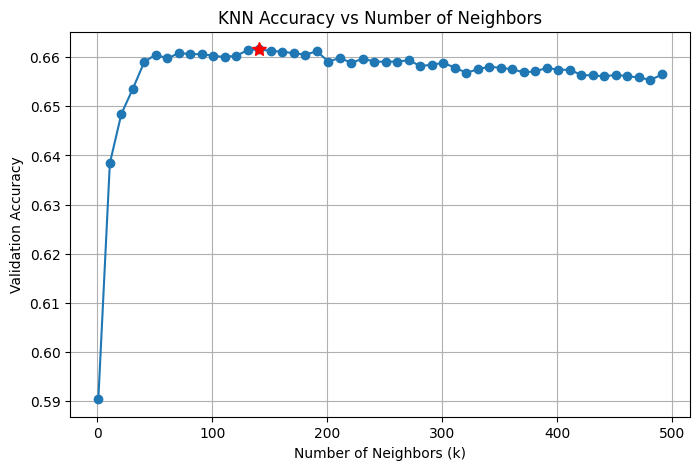

In [15]:
idx_max = np.argmax(list(n_and_accuracies.values()))
k_max = list(n_and_accuracies.keys())[idx_max]
print(f"Best performance is for k={k_max}")

plt.figure(figsize=(8, 5))
plt.plot(list(n_and_accuracies.keys()), list(n_and_accuracies.values()), marker='o')
plt.grid()
plt.ylabel("Validation Accuracy")
plt.xlabel("Number of Neighbors (k)")
plt.title("KNN Accuracy vs Number of Neighbors")
plt.plot(k_max, n_and_accuracies[k_max], marker='*', markersize=10, color='red')
plt.show()

We can see from the results on the graph that the best performance is for $k = 141$, where we have an accuracy of 66%.

Now, we could train our model for that specific value of $k$ with all the training and validation data, to get our final version of the model.

In [16]:
final_model = KNeighborsClassifier(n_neighbors=k_max)
final_model.fit(X_train_and_eval, y_train_and_eval)

,n_neighbors,141
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


If we're sure this is the best model we can get, we would then use it to check the performance in the test dataset, which we'll do in the next notebook.

Let's move to other domains!

# Audio: Instrument Family Classification

Let's repeat the process for the audio data, but directly using k-folds!

Remember we're working with the TinySOL dataset, and we have calculated the Spectral Centroid, Spectral Bandwidth, RMS and Zero-Crossing rate features.

First, let's retrieve our data.

In [17]:
tinysol_dataset = pd.read_csv("features_and_labels_audio.csv")
tinysol_dataset.head()

,Spectral Centroid,Spectral Bandwidth,RMS,Zero-Crossing Rate,Family
0,5633.172265,3118.915778,1.649794,0.008589,Brass
1,5643.018662,3119.580742,1.627017,0.008592,Brass
2,5685.157258,3094.128050,1.610967,0.011369,Brass
3,5646.330359,3118.488256,1.627235,0.019568,Brass
4,5689.932701,3087.401249,1.633211,0.012646,Brass


Let's create our `X` and `y` vectors:

In [18]:
y_audio = tinysol_dataset["Family"]
X_audio = tinysol_dataset.drop(columns=["Family"])

Since we're only working with cross-validation, let's directly do a train/test split.

In [19]:
# First split: 85% train, 15% test
X_train_audio, X_test_audio, y_train_audio, y_test_audio = train_test_split(X_audio, y_audio, test_size=0.30, random_state=0)

print(f"Training feature size: {X_train_audio.shape}")
print(f"Training label size: {y_train_audio.shape}")
print(f"Test feature size: {X_test_audio.shape}")
print(f"Test label size: {y_test_audio.shape}")

Training feature size: (2039, 4)
Training label size: (2039,)
Test feature size: (874, 4)
Test label size: (874,)


## Data Standardisation 🔤

Before doing any training, let's check some statistics of our data:

In [20]:
X_train_audio.describe()

,Spectral Centroid,Spectral Bandwidth,RMS,Zero-Crossing Rate
count,2039.000000,2039.000000,2039.000000,2039.000000
mean,6109.649231,2986.569479,1.296006,0.056910
std,269.175249,98.035310,0.205610,0.037777
min,5580.122784,2589.500542,0.564154,0.005499
25%,5927.354098,2929.199774,1.143555,0.028089
50%,6088.157945,2995.631296,1.326616,0.047321
75%,6259.489290,3054.439889,1.469061,0.074120
max,7979.788501,3260.818208,1.649794,0.225253


> Do you notice anything in the training data that could be problematic to our training process?

Well, it doesn't make sense to compare the Spectral Centroid with the Zero-Crossing Rate if the maximum for one is near 8000 and the other one is 0.23! We need to **standardise** the data before continuing.

The **standardisation** process transforms a feature to have a **mean of 0** and a **standard deviation of 1**.

The formula is very simple. First, recall the formulae for calculating the mean $\bar{x}$ and standard deviation $s$ of a feature $x$:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \quad , \\
s = \sqrt{\frac{\sum_{i=1}^{n}{(x_i-\bar{x})^2}}{n-1}} \quad ,
$$

where $x_i$ is the value for feature $x$ at index $i$ and $n$ is the total number of values in $x$.

Then, we can calculate Z-scores as:

$$
Z_{x_i} = \dfrac{x_i - \bar{x}}{s} \quad .
$$

Let's apply **Z-scoring** to our the Spectral Centroid to understand the difference:

In [21]:
spectral_centroids = X_train_audio["Spectral Centroid"]
centroids_z = (spectral_centroids - np.mean(spectral_centroids)) / np.std(spectral_centroids)

Now, let's visualise the original feature and the standardised one:

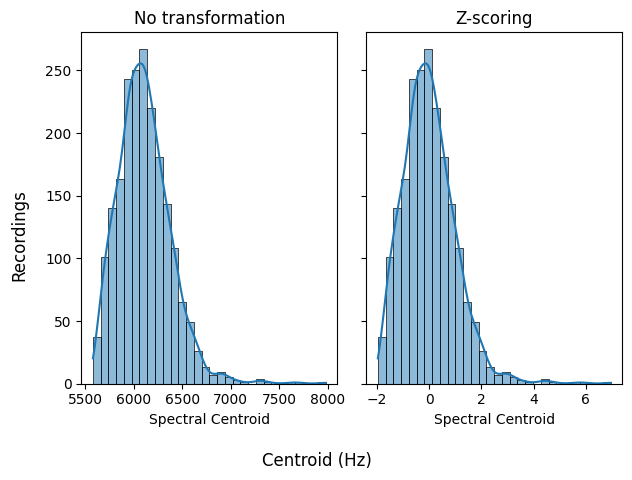

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
sns.histplot(spectral_centroids, kde=True, ax=ax[0], bins=30)
sns.histplot(centroids_z, kde=True, ax=ax[1], bins=30)

ax[0].set(title="No transformation", ylabel="")
ax[1].set(title="Z-scoring", ylabel="")

fig.supylabel("Recordings")
fig.supxlabel("Centroid (Hz)")
plt.tight_layout()
plt.show()

The overall shape of the distribution is the same, but the values of the features are different!

Let's standardise all our features:

In [23]:
X_train_audio_standardised = (X_train_audio - X_train_audio.mean()) / X_train_audio.std()
X_train_audio_standardised.describe()

,Spectral Centroid,Spectral Bandwidth,RMS,Zero-Crossing Rate
count,2.039000e+03,2.039000e+03,2.039000e+03,2.039000e+03
mean,2.231989e-15,-3.783579e-15,-1.903551e-16,1.045428e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.967218e+00,-4.050265e+00,-3.559415e+00,-1.360895e+00
25%,-6.772359e-01,-5.851943e-01,-7.414548e-01,-7.629275e-01
50%,-7.984124e-02,9.243422e-02,1.488715e-01,-2.538175e-01
75%,5.566636e-01,6.923058e-01,8.416632e-01,4.555673e-01
max,6.947664e+00,2.797448e+00,1.720670e+00,4.456214e+00


Let's visualise our train data after standardisation, plotting `pairplots` of the four features we have, as we did in the previous notebook.

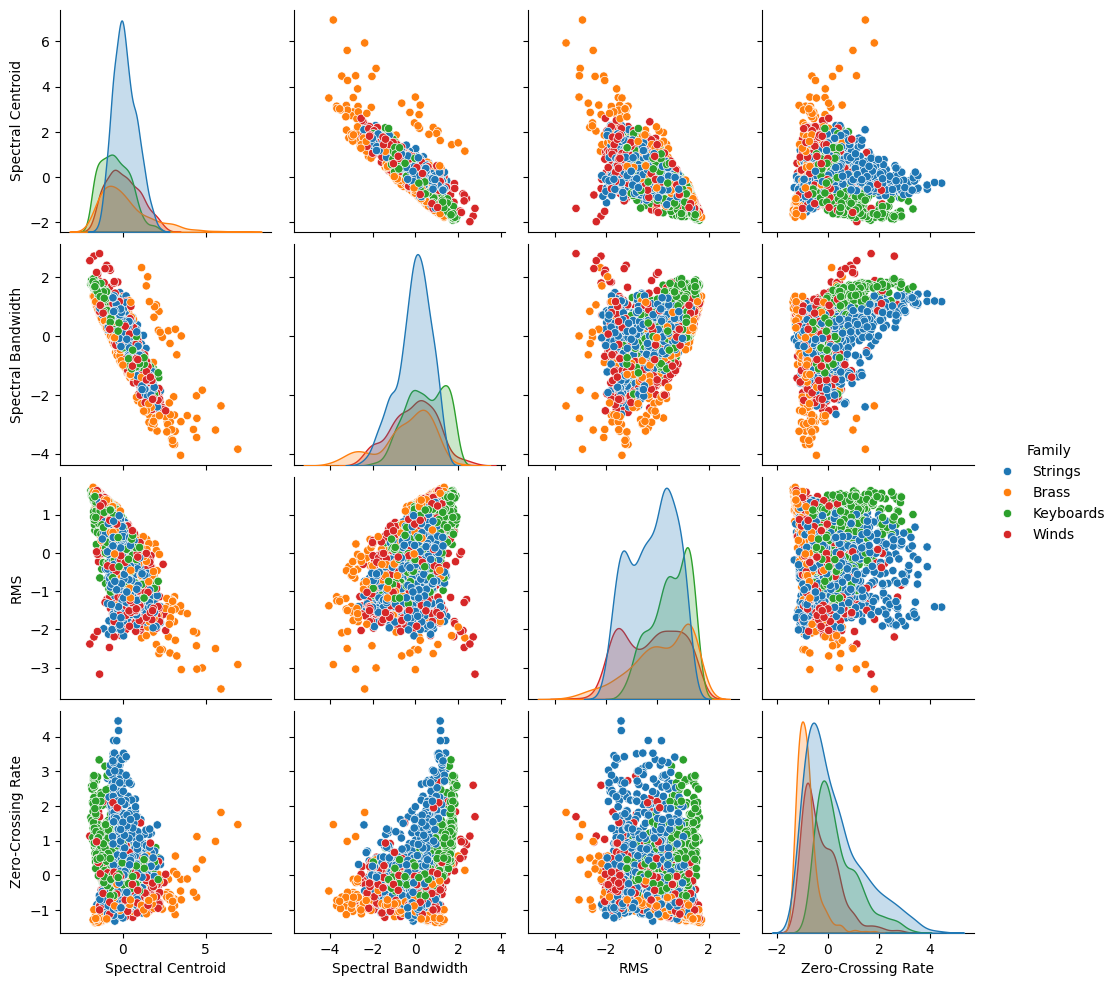

In [24]:
train_data_standardised = X_train_audio_standardised.copy()
train_data_standardised['Family'] = y_train_audio
sns.pairplot(train_data_standardised, hue='Family')

Now they are all comparable, and we are ready to train the model!

## Hyperparameter tuning: choice of $k$ neighbours

Let's repeat the cross-validation and hyperparameter tuning processes for the audio data. What's the best $k$ in this case?

In [25]:
# Set up k-fold with 5 splits
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

n_neighbors = range(1, 20, 2)
n_and_accuracies_audio = {}

for k in n_neighbors:
    print(f"Evaluating KNN with k={k} neighbours")
    model_audio = KNeighborsClassifier(n_neighbors=k)
    n_and_accuracies_audio[k] = []
    # iterate over each fold
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_audio_standardised)):
        # train the model with the training indices for this fold
        model_audio.fit(X_train_audio_standardised.iloc[train_idx], y_train_audio.iloc[train_idx])
        # predict on the validation set for this fold
        predictions = model_audio.predict(X_train_audio_standardised.iloc[val_idx])
        # compute accuracy for this fold
        accuracy = accuracy_score(y_train_audio.iloc[val_idx], predictions)
        # store the accuracy for this fold
        n_and_accuracies_audio[k].append(accuracy)

    n_and_accuracies_audio[k] = np.mean(n_and_accuracies_audio[k])

Evaluating KNN with k=1 neighbours
Evaluating KNN with k=3 neighbours
Evaluating KNN with k=5 neighbours
Evaluating KNN with k=7 neighbours
Evaluating KNN with k=9 neighbours
Evaluating KNN with k=11 neighbours
Evaluating KNN with k=13 neighbours
Evaluating KNN with k=15 neighbours
Evaluating KNN with k=17 neighbours
Evaluating KNN with k=19 neighbours


Let's visualise the accuracies we achieve for different amount of neighbours.

Best performance is for k=5


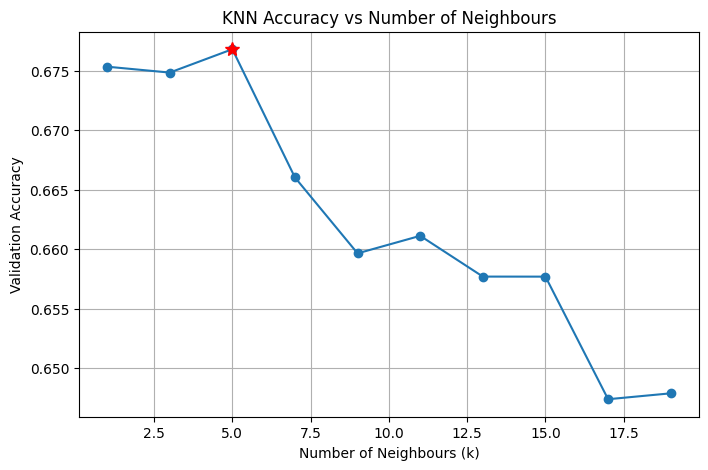

In [26]:
idx_max_audio = np.argmax(list(n_and_accuracies_audio.values()))
k_max_audio = list(n_and_accuracies_audio.keys())[idx_max_audio]
print(f"Best performance is for k={k_max_audio}")

plt.figure(figsize=(8, 5))
plt.plot(list(n_and_accuracies_audio.keys()), list(n_and_accuracies_audio.values()), marker='o')
plt.grid()
plt.ylabel("Validation Accuracy")
plt.xlabel("Number of Neighbours (k)")
plt.title("KNN Accuracy vs Number of Neighbours")

plt.plot([k_max_audio], [n_and_accuracies_audio[k_max_audio]], marker='*', color='red', markersize=10)
plt.show()

If we analyse the graph, it is clear that we have a maximum of accuracy at $k = 5$, where the model is accurate just over 67.5% of the times. If we use more neighbours we will not be only needing more compute, will will also get worse results!

To get our final model, then, we can train the k-NN model with $k=5$ for all our training data.

In [27]:
final_model_audio = KNeighborsClassifier(n_neighbors=k_max_audio)
final_model_audio.fit(X_train_audio, y_train_audio)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


And there you go, ready for the real world!

Let's continue with images.

# Image classification: Automobile or aeroplane?

Let's load our processed images dataset! Remember we had a separate train and test folder for the CIFAR10 dataset, and we only processed the `train` folder? We are free to use all the train data now, so we don't need to do any splits.

In [28]:
cifar_dataset = pd.read_csv("features_and_labels_images.csv")
cifar_dataset.head()

,mean_R,mean_G,mean_B,std_R,std_G,std_B,edge_density_0,edge_density_1,edge_density_2,edge_density_3,edge_density_4,edge_density_5,edge_density_6,edge_density_7,edge_density_8,label
0,118.180664,119.496094,122.874023,51.516244,50.720030,49.866646,0.12,0.48,0.28,0.48,0.61,0.52,0.00,0.00,0.00,automobile
1,153.441406,141.306641,125.672852,61.136538,64.113088,65.829187,0.55,0.53,0.45,0.44,0.40,0.24,0.10,0.53,0.48,automobile
2,86.692383,41.961914,20.034180,69.927963,33.743627,19.912891,0.03,0.00,0.08,0.05,0.22,0.37,0.14,0.30,0.12,automobile
3,107.335938,97.231445,70.627930,69.433453,64.765579,38.634369,0.33,0.50,0.58,0.49,0.54,0.40,0.53,0.57,0.03,automobile
4,109.796875,129.926758,125.689453,61.164032,71.888990,88.644751,0.00,0.02,0.24,0.61,0.52,0.43,0.20,0.30,0.23,automobile


Let's define our `X` and `y` vectors.

In [29]:
y_train_images = cifar_dataset["label"]
X_train_images = cifar_dataset.drop(columns=["label"])

print(f"Training feature size: {X_train_images.shape}")
print(f"Training label size: {y_train_images.shape}")


Training feature size: (10000, 15)
Training label size: (10000,)


Let's standardise the features, as before:

In [30]:
X_train_images_standardised = (X_train_images - X_train_images.mean()) / X_train_images.std()
X_train_images_standardised.describe()

,mean_R,mean_G,mean_B,std_R,std_G,std_B,edge_density_0,edge_density_1,edge_density_2,edge_density_3,edge_density_4,edge_density_5,edge_density_6,edge_density_7,edge_density_8
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,1.477929e-16,-2.273737e-16,9.094947e-17,-4.547474e-17,-6.821210e-17,4.774847e-16,9.094947e-17,-4.547474e-17,-4.547474e-17,1.818989e-16,2.046363e-16,-6.821210e-17,1.818989e-16,-1.818989e-16,-1.364242e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.294342e+00,-3.188101e+00,-3.009651e+00,-3.104043e+00,-2.948821e+00,-3.102731e+00,-1.098483e+00,-1.271849e+00,-1.175013e+00,-2.235020e+00,-2.854336e+00,-2.401097e+00,-1.462378e+00,-1.865643e+00,-1.510516e+00
25%,-6.667711e-01,-6.933844e-01,-7.263307e-01,-6.516663e-01,-6.673928e-01,-6.545757e-01,-9.801460e-01,-9.546834e-01,-9.610280e-01,-6.554514e-01,-6.903112e-01,-6.785562e-01,-8.587969e-01,-7.725325e-01,-8.484983e-01
50%,-7.702027e-02,-8.044427e-02,-6.426605e-02,3.108758e-02,6.285321e-03,3.518058e-02,-2.109539e-01,-5.604839e-02,-1.585843e-01,3.955871e-02,7.346228e-02,3.421916e-02,-3.573199e-02,8.260793e-03,-3.370690e-02
75%,6.219930e-01,6.609776e-01,7.234189e-01,6.776738e-01,6.629650e-01,6.674879e-01,7.357441e-01,7.897257e-01,7.508520e-01,7.345688e-01,7.099402e-01,7.469946e-01,7.873329e-01,7.370012e-01,7.810845e-01
max,3.446854e+00,3.365314e+00,2.825997e+00,3.917336e+00,3.995563e+00,3.749825e+00,3.339164e+00,3.327048e+00,2.944198e+00,2.882782e+00,3.001261e+00,2.944719e+00,2.927302e+00,2.819116e+00,2.970836e+00


Now, let's find the best value of $k$ for our dataset:

In [31]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

n_neighbors = range(1, 50, 2)
n_and_accuracies_images = {}

for k in n_neighbors:
    print(f"Evaluating KNN with k={k} neighbours")
    model_images = KNeighborsClassifier(n_neighbors=k)
    n_and_accuracies_images[k] = []
    # iterate over each fold
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_images_standardised)):
        # train the model with the training indices for this fold
        model_images.fit(X_train_images_standardised.iloc[train_idx], y_train_images.iloc[train_idx])
        # predict on the validation set for this fold
        predictions = model_images.predict(X_train_images_standardised.iloc[val_idx])
        # compute accuracy for this fold
        accuracy = accuracy_score(y_train_images.iloc[val_idx], predictions)
        # store the accuracy for this fold
        n_and_accuracies_images[k].append(accuracy)

    n_and_accuracies_images[k] = np.mean(n_and_accuracies_images[k])

Evaluating KNN with k=1 neighbours


Evaluating KNN with k=3 neighbours
Evaluating KNN with k=5 neighbours
Evaluating KNN with k=7 neighbours
Evaluating KNN with k=9 neighbours
Evaluating KNN with k=11 neighbours
Evaluating KNN with k=13 neighbours
Evaluating KNN with k=15 neighbours
Evaluating KNN with k=17 neighbours
Evaluating KNN with k=19 neighbours
Evaluating KNN with k=21 neighbours
Evaluating KNN with k=23 neighbours
Evaluating KNN with k=25 neighbours
Evaluating KNN with k=27 neighbours
Evaluating KNN with k=29 neighbours
Evaluating KNN with k=31 neighbours
Evaluating KNN with k=33 neighbours
Evaluating KNN with k=35 neighbours
Evaluating KNN with k=37 neighbours
Evaluating KNN with k=39 neighbours
Evaluating KNN with k=41 neighbours
Evaluating KNN with k=43 neighbours
Evaluating KNN with k=45 neighbours
Evaluating KNN with k=47 neighbours
Evaluating KNN with k=49 neighbours


Let's visualise the results:

Best performance is for k=27


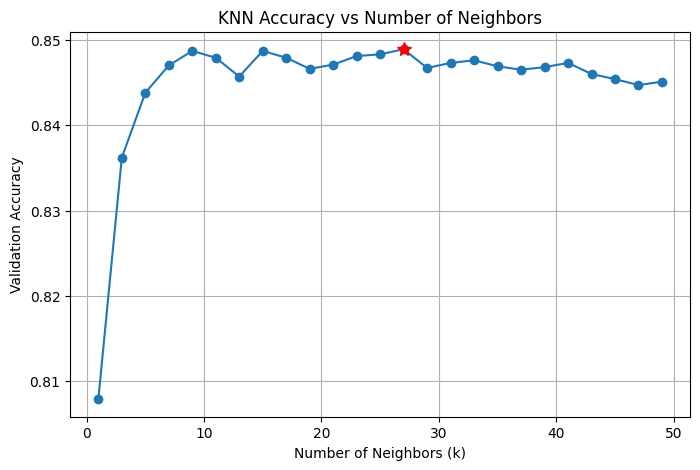

In [32]:
idx_max_images = np.argmax(list(n_and_accuracies_images.values()))
k_max_images = list(n_and_accuracies_images.keys())[idx_max_images]
print(f"Best performance is for k={k_max_images}")

plt.figure(figsize=(8, 5))
plt.plot(list(n_and_accuracies_images.keys()), list(n_and_accuracies_images.values()), marker='o')
plt.grid()
plt.ylabel("Validation Accuracy")
plt.xlabel("Number of Neighbors (k)")
plt.title("KNN Accuracy vs Number of Neighbors")

plt.plot([k_max_images], [n_and_accuracies_images[k_max_images]], marker='*', color='red', markersize=10)
plt.show()

Looks like $k=27$ works best for this dataset, with an accuracy of near 85%.

Let's train the model for all the train data with that value of $k$

In [33]:
final_model_images = KNeighborsClassifier(n_neighbors=k_max_images)
final_model_images.fit(X_train_images, y_train_images)

,n_neighbors,27
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


And we're done for now!

# Summary

We have successfully trained classification models for the following tasks:
* Movie review classification (is it positive or negative?)
* Instrument family classification (is it a string, brass, keyboard or wind instrument?)
* Image classification (is it an aeroplane or an automobile?)

For this, in all three cases, we loaded the preprocessed datasets consisting in:
* Several rows, one per each observation (or data sample)
* Several columns, one per each feature
* One more column, indicating the output of the system for that observation

And we later learnt how to:
* Split that data into train, test and validation datasets.
* Standardise our features.
* Train a k-NN classification model, using the train data for the training process and the validation data for evaluation.
* Train a k-NN classification model using cross-validation.
* Perform Hyperparameter Tuning, to find the best value of $k$ for each case.
* Train the model with the best parameters for all the available data.

Once we decide we're finished training the model and we have found the best possible performance on the validation set, we can move on and evaluate how our model performs for the previously unseen test dataset. But, when can we say our model is good enough? To what are we comparing it with? There are other important metrics we can use to evaluate our model as well, as accuracy is not the only important thing we want to measure. More on this in the next notebook!